In [33]:
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [34]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [35]:
weights="imagenet"

In [36]:
include_top=False

In [37]:
base_model.trainable = False

In [38]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation="relu"
)(x)

output = Dense(
    2,
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

In [39]:
Dense(2)

<Dense name=dense_9, built=False>

In [40]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

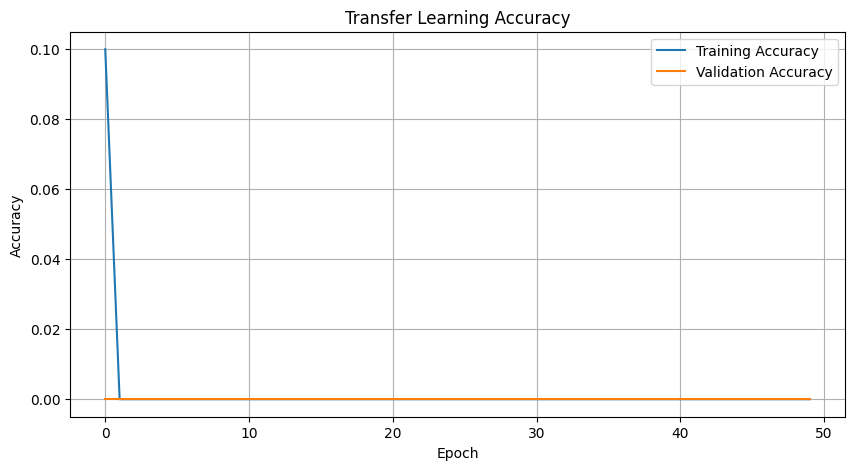

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Transfer Learning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()